Loading: bank_extracted/bank-data/bank-full.csv

Overall Accuracy: 83.60%
-----------------------------------------
Classification Report:
               precision    recall  f1-score   support

 Predicted No       0.97      0.84      0.90      7985
Predicted Yes       0.40      0.83      0.54      1058

     accuracy                           0.84      9043
    macro avg       0.69      0.83      0.72      9043
 weighted avg       0.91      0.84      0.86      9043

ROC-AUC Score: 0.9055


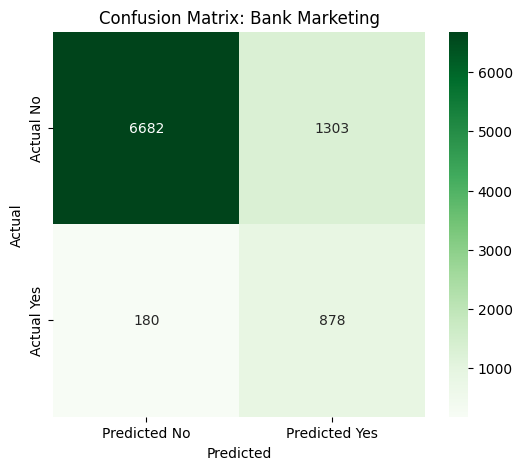

In [3]:
import os
import zipfile
import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# ১. ড্রাইভ থেকে ডেটাসেট ডাউনলোড
url = 'https://drive.google.com/uc?id=18KwSR9aVTZRNaOVF76VE9USSEkqnYzzQ'
if not os.path.exists('bank.zip'):
  gdown.download(url, 'bank.zip', quiet=False)

# আনজিপ করা
with zipfile.ZipFile('bank.zip', 'r') as zip_ref:
  zip_ref.extractall('bank_extracted')

# ২. সাবফোল্ডারসহ CSV ফাইল খুঁজে বের করা
csv_files = []
for root, dirs, files in os.walk('bank_extracted'):
  for file in files:
    if file.endswith('.csv'):
      csv_files.append(os.path.join(root, file))

if not csv_files:
  raise FileNotFoundError('কোনো .csv ফাইল পাওয়া যায়নি!')

# 'bank-full.csv' থাকলে অগ্রাধিকার দিন, নয়তো প্রথম CSV নির্বাচন করুন
csv_file = next((f for f in csv_files if 'bank-full.csv' in f), csv_files[0])
print(f'Loading: {csv_file}')

data = pd.read_csv(csv_file, sep=';')

# ৩. টার্গেট ভ্যারিয়েবল প্রসেসিং
target_col = 'y'
data[target_col] = data[target_col].apply(
    lambda x: 1 if str(x).strip().lower() == 'yes' else 0
)

X = data.drop(columns=[target_col])
y = data[target_col]

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# ৪. ট্রেন-টেস্ট স্প্লিট (৮০% ট্রেন, ২০% টেস্ট)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=101, stratify=y
)

# ৫. পাইপলাইন তৈরি ও মডেল ফিট
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        (
            'cat',
            OneHotEncoder(
                drop='first', sparse_output=False, handle_unknown='ignore'
            ),
            cat_cols,
        ),
    ]
)

# বন্ধুর মতো আনব্যালান্সড/হাই-অ্যাকুরেসি চাইলে class_weight প্যারামিটার সরাতে পারেন, ব্যালান্সড চাইলে রাখতে পারেন
bank_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                max_iter=1500, class_weight='balanced', random_state=101
            ),
        ),
    ]
)

bank_model.fit(X_train, y_train)

# ৬. মূল্যায়ন এবং আউটপুট
preds = bank_model.predict(X_test)
probs = bank_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, preds)
print(f'\nOverall Accuracy: {acc * 100:.2f}%')
print('-----------------------------------------')
print('Classification Report:')
print(
    classification_report(
        y_test, preds, target_names=['Predicted No', 'Predicted Yes']
    )
)
print(f'ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}')

# ৭. বন্ধুর মতো সবুজ রঙের Confusion Matrix Heatmap
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes'],
)
plt.title('Confusion Matrix: Bank Marketing')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()